In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
    
)

In [2]:
df = pd.read_csv("data/iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 5)

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 3


In [5]:
print(df["species"].value_counts())

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [6]:
# Remove duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)

# Check missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values after cleaning:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Dataset shape after cleaning: (147, 5)


In [7]:
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = df["species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 117
Testing samples: 30


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [10]:
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions:")
print(y_pred_logistic)

Logistic Regression predictions:
['Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor']


In [11]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test, y_pred_logistic, average="weighted"
)
logistic_recall = recall_score(
    y_test, y_pred_logistic, average="weighted"
)
logistic_f1 = f1_score(
    y_test, y_pred_logistic, average="weighted"
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1-Score :", logistic_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression
-------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-Score : 0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



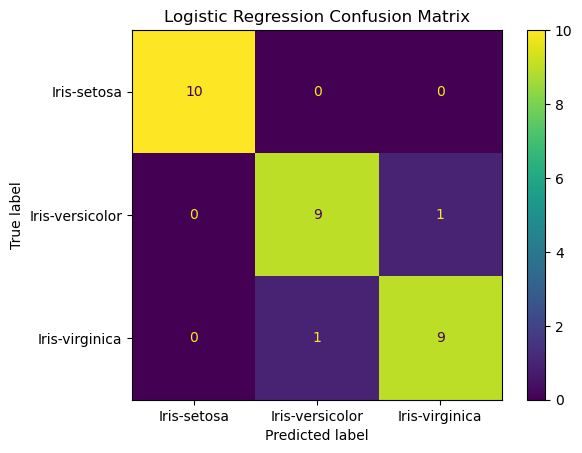

In [12]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=logistic_model.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions:")
print(y_pred_knn)

KNN predictions:
['Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor']


In [14]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(
    y_test, y_pred_knn, average="weighted"
)
knn_recall = recall_score(
    y_test, y_pred_knn, average="weighted"
)
knn_f1 = f1_score(
    y_test, y_pred_knn, average="weighted"
)

print("K-Nearest Neighbors")
print("-------------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-Score :", knn_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors
-------------------
Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333333
F1-Score : 0.9326599326599326

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



In [15]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(
    y_test, y_pred_knn, average="weighted"
)
knn_recall = recall_score(
    y_test, y_pred_knn, average="weighted"
)
knn_f1 = f1_score(
    y_test, y_pred_knn, average="weighted"
)

print("K-Nearest Neighbors")
print("-------------------")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1-Score :", knn_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors
-------------------
Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333333
F1-Score : 0.9326599326599326

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



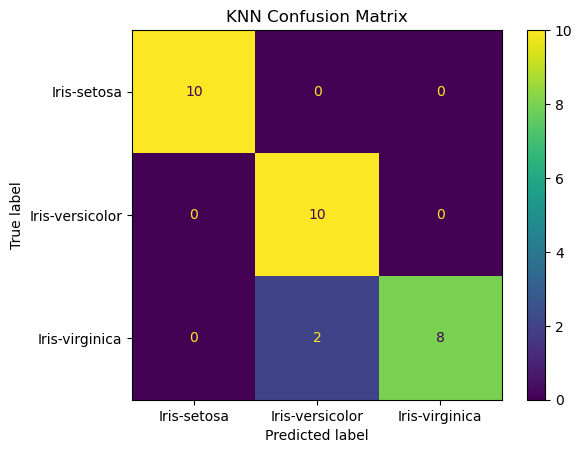

In [16]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall
    ],
    "F1-Score": [
        logistic_f1,
        knn_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660


## Findings and Future Improvements

The experiment compared Logistic Regression and K-Nearest Neighbors for Iris flower species classification. Both models were trained using the four numerical flower measurements after standardizing the features. The evaluation results show that both models can classify the Iris species effectively on this dataset. The accuracy, precision, recall, F1-score, and confusion matrices were used to compare their performance. The small size and simplicity of the Iris dataset limit how well these results can represent performance on larger real-world datasets. With more time, I would test additional models, perform hyperparameter tuning, and evaluate the models using cross-validation.